##  Final Project (3/3): Damping and Adaptive Step Size

 <span style="font-family: 'Times New Roman'; font-size: 20px;">
    Mansha Arora, ma72449
</span>

Project Type: Individual 


## Section 1:  Review of Part 2

In Part 2, we modeled a stiff scalar ODE representing an RC circuit with a high-speed transient response.
##### 1.1 The Governing Equation
The circuit is governed by the following first-order ODE:$$\frac{dV}{dt} = -\frac{1}{RC}V + \frac{1}{RC}V_{\text{source}}(t)$$

Substituting the given parameters ($R = 100\,\Omega$, $C = 10^{-9}\,\text{F}$, and $V_{\text{source}}(t) = 5\sin(t)$):$$\frac{dV}{dt} = -10^7 V + 5 \times 10^7 \sin(t), \quad V(0) = 0$$

##### 1.2 The Implicit Formulation
To solve this implicitly using Euler's Backward method, we must find the root of the residual function $g(V_{n+1})$ at each time step:$$g(V_{n+1}) = V_{n+1} - V_n - h \cdot f(t_{n+1}, V_{n+1}) = 0$$For our specific ODE, the residual function is:$$g(V_{n+1}) = V_{n+1} - V_n - h \left[ -10^7 V_{n+1} + 5 \times 10^7 \sin(t_{n+1}) \right]$$The Jacobian (derivative) of the residual function is:$$g'(V_{n+1}) = \frac{dg}{dV_{n+1}} = 1 - h\lambda$$Where the system eigenvalue is $\lambda = -10^7$.

#### Analysis of Stiffness
The stiffness of the system is characterized by the massive disparity in time scales:Circuit Time Constant ($\tau$): $RC = 10^{-7}\,\text{s}$ (Fast transient)Forcing Signal Period ($T$): $\approx 2\pi\,\text{s}$ (Slow input)Stiffness Ratio: $\frac{T}{\tau} \approx 6.28 \times 10^7$Stability Constraint:An explicit method (like Euler's Forward) would be restricted by the stability criterion:$$h < \frac{2}{|\lambda|} = 2 \times 10^{-7}\,\text{s}$$Simulating just one period ($2\pi$ seconds) with a fixed step size would require over 31.4 million iterations. By using Euler's Backward method, which is A-stable, we bypass this stability limit, though we still face accuracy challenges during the initial fast transient.  


(asked gemini to help format my equations)

In [28]:
import numpy as np
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from matplotlib.gridspec import GridSpec # asked chat gpt what library would help me with improving my plots 

lam = -1e7    # stiffness coefficient
A   = 5.0     # source amplitude

def f(t, V): #RHS of dV/dt = lambda*V + |lambda|*A*sin(t) 
    return lam * V + abs(lam) * A * np.sin(t)

def exact_solution(t, V0=0.0): #High-accuracy reference solution via scipy Radau
    
    sol = solve_ivp(f, [t[0], t[-1]], [V0], t_eval=t,method='Radau', rtol=1e-12, atol=1e-14)
    return sol.y[0]

def g_func(y, y_n, t_next, h): #Residual g(y) = y - y_n - h*f(t_next, y) 
    return y - y_n - h * f(t_next, y)

def g_prime(h): #Jacobian g'(y) = 1 - h*lambda (constant for linear ODE)
    return 1.0 - h * lam


## Section 2: Newton-Raphson Solvers

##### 2.1 Newton-Raphson Damping and Line Search

Newton-Raphson is a powerful local root-finding method. However, because it relies on a linear approximation of the residual, it can become unstable when the initial guess is far from equilibrium.

##### 2.2 The Problem: Divergence and Overshooting
The standard Newton-Raphson update at each iteration $k$ is given by:$$y^{(k+1)} = y^{(k)} - \frac{g(y^{(k)})}{g'(y^{(k)})}$$When solving stiff ODEs, the residual function $g(y)$ becomes highly sensitive as the step size $h$ increases. If the initial guess $y^{(0)}$ is far from the solution, a full Newton step can overshoot the root. This results in:Oscillatory Behavior: The solution bounces back and forth around the root.Divergence: The residual magnitude $|g(y)|$ increases rather than decreases.Convergence Failure: The method fails to meet the tolerance within the maximum iteration limit.

##### 2.3 The Solution: Damping with Backtracking Line Search
To stabilize the solver, we introduce a damping factor $\alpha \in (0, 1]$ to scale the update. The damped Newton-Raphson update is defined as:$$y^{(k+1)} = y^{(k)} + \alpha \delta, \quad \text{where } \delta = -\frac{g(y^{(k)})}{g'(y^{(k)})}$$The direction $\delta$ is the standard Newton direction. We determine the optimal $\alpha$ using a backtracking line search algorithm:Start with $\alpha = 1$ (the full Newton step).Evaluate the Sufficient Decrease Condition:$$|g(y^{(k)} + \alpha \delta)| < |g(y^{(k)})|$$If the condition is not met, reduce $\alpha$ (e.g., $\alpha \leftarrow \alpha / 2$) and repeat.Stop if $\alpha$ falls below a minimum threshold $\alpha_{\min} = 10^{-4}$ to avoid infinite loops.

##### 2.4 Demonstration: Damped vs. Undamped NRTo 
demonstrate the robustness of damping, we test the solver on a nonlinear ODE:$$\frac{dy}{dt} = -50(y - \sin t)^3$$Using a large step size $h = 0.5$, we compare both methods:Standard NR: Exhibits non-monotone convergence and can oscillate wildly before (or if) it finds the root.Damped NR: Ensures that the residual $|g(y)|$ decreases monotonically at every iteration.Convergence Profile: Early in the process, the solver uses $\alpha < 1$ to stay within the "safe" region of the function. As $y^{(k)}$ approaches the root, the line search naturally recovers $\alpha = 1$, allowing the method to regain its characteristic quadratic convergence speed. This makes the damped solver significantly more robust than the standard implementation.

(asked gemini to help with formatting equations)

In [24]:
def basic_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=50): # undamped Newton-Raphson w/ one Euler step
    
    y = y_n
    for k in range(max_iter):
        g  = g_func(y, y_n, t_next, h)
        if abs(g) < tol:
            return y, k, True
        gp = g_prime(h)
        y  = y - g / gp    # full Newton step (alpha = 1)
    return y, max_iter, False  


def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=50, alpha_min=1e-4, max_backtrack=20): # backtracking line search 
        
    y = y_n
    total_backtrack = 0
    final_alpha = 1.0

    for k in range(max_iter):
        g  = g_func(y, y_n, t_next, h)
        if abs(g) < tol:
            return y, k, True, total_backtrack, final_alpha

        gp    = g_prime(h)
        delta = -g / gp            # full Newton direction

        # Backtracking line search 
        alpha     = 1.0 # one full step 
        g_current = abs(g)
        found     = False

        for _ in range(max_backtrack):
            y_trial = y + alpha * delta
            g_trial = abs(g_func(y_trial, y_n, t_next, h))
            if g_trial < g_current:    # any decrease is sufficient
                found = True
                break
            alpha           /= 2.0
            total_backtrack += 1
            if alpha < alpha_min:
                return y, k, False, total_backtrack, alpha

        if not found:
            return y, k, False, total_backtrack, alpha

        final_alpha = alpha
        y = y + alpha * delta      # accept damped step

    return y, max_iter, False, total_backtrack, final_alpha


def one_implicit_euler_step(y_n, t_next, h, tol_nr=1e-10, max_iter=50): # one damped Newton-Rapshon w/ implicit Euler
    
    y, iters, conv, _, _ = damped_newton_raphson(
        y_n, t_next, h, tol=tol_nr, max_iter=max_iter
    )
    return y, iters

## Section 3: Combined Implementation
#### The Complete Adaptive Implicit Solver

In [34]:
def estimate_error_step_doubling(y_n, t_n, h): # using truncation error with step-doubling 
    
    # Single step of size h
    y_full, iters_full = one_implicit_euler_step(y_n, t_n + h, h)

    # First half-step: t_n --> t_n + h/2
    y_mid,  iters_1   = one_implicit_euler_step(y_n,  t_n + h/2, h/2)
    # Second half-step: t_n + h/2 --> t_n + h
    y_half, iters_2   = one_implicit_euler_step(y_mid, t_n + h,   h/2)

    error = abs(y_half - y_full)
    return y_full, y_half, error, iters_full + iters_1 + iters_2

#original adjust step size: 

#def adjust_step_size(h, error, tol, safety=0.9, h_min=1e-10, h_max=0.5): # compute new step sizes + values plugged in prevent extremes and issues 
    
    #eps   = 1e-10                               # avoid division by zero
    #h_new = h * np.sqrt(tol / (error + eps))
    #h_new = safety * h_new                      # conservative
    #h_new = max(h_min, min(h_max, h_new))       # hard bounds
    #h_new = max(0.2 * h, min(5.0 * h, h_new))  # limit rate of change
    #return h_new
    
    
# BONUS: 

def adjust_step_size_PI(h, error, tol, err_prev, safety=0.9, h_min=1e-10, h_max=0.5):
    # If it's the very first step, err_prev might be None or the same as error
    if err_prev is None:
        err_prev = error 
        
    # PI Controller Formula from your Screenshot
    # h_new = h * (tol/err)**kP * (err_prev/err)**kI
    term_p = (tol / (error + 1e-15))**0.7
    term_i = (err_prev / (error + 1e-15))**0.4
    
    h_new = h * term_p * term_i
    
    # Apply safety and bounds
    h_new = safety * h_new
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h, min(5.0 * h, h_new)) # Limit rate of change
    return h_new


def adaptive_implicit_euler(y0 , t0, t_final, h0, tol, h_min=1e-10, h_max=0.5, safety=0.9, max_steps=200_000, err_prev = tol): # adaptive euler backward solver 
    # combines damped newton-rampson solver + step-doubling
   
    t   = [t0];  y = [y0];  h = h0
    h_history   = []
    err_history = []
    stats = dict(accepted=0, rejected=0, nr_iters=0, func_evals=0)

    step_count = 0
    while t[-1] < t_final and step_count < max_steps:
        step_count += 1
        tn = t[-1]
        yn = y[-1]

        # Don't overshoot t_final
        h = min(h, t_final - tn)
        if h < h_min:
            break

        # Error estimation w/ step-doubling 
        y_full, y_half, error, iters = estimate_error_step_doubling(yn, tn, h)
        stats['nr_iters']   += iters
        stats['func_evals'] += 3    # 3 NR solves per error estimate

        # Proposed step size for next attempt 
        h_new = adjust_step_size(h, error, tol, safety, h_min, h_max)

        if error < tol:
            # ACCEPT: use y^(h/2) — more accurate than y^(h)
            t.append(tn + h)
            y.append(y_half)
            h_history.append(h)
            err_history.append(error)
            stats['accepted'] += 1
            h = h_new           # try a larger step next time
        else:
            # REJECT: retry from same t_n with smaller h
            stats['rejected'] += 1
            h = h_new           # h_new < h since error > tol

    return (np.array(t), np.array(y),
            np.array(h_history), np.array(err_history), stats)


def fixed_implicit_euler(y0, t0, t_final, h, nr_tol=1e-10): #used for comparison 
    
    t_arr = [t0];  y_arr = [y0];  total_iters = 0
    t_cur = t0;    y_cur = y0

    while t_cur + h <= t_final + 1e-14:
        t_next = min(t_cur + h, t_final)
        y_next, iters = one_implicit_euler_step(y_cur, t_next, h, tol_nr=nr_tol)
        t_cur = t_next;  y_cur = y_next
        t_arr.append(t_cur);  y_arr.append(y_cur)
        total_iters += iters

    return np.array(t_arr), np.array(y_arr), total_iters

## Section 3: Adaptive Step Size Implementation

##### 3.1 Why Do We Need Adaptive Stepping?
When we are working with a fixed step size we have to choose a size that works for the possible situation. This is the part of the solution where things are changing fast. For our RC circuit this means we need a step size of about $10^{-7}$ seconds at the beginning.. The truth is, most of the time the solution is pretty smooth and we could use a step size that is thousands of times bigger and still get accurate results. Adaptive stepping helps us avoid wasting time on calculations by automatically changing the step size. We use a step size when the solution is changing rapidly. We use a step size when the solution is smooth.

##### 3.2 Step-Doubling Error Estimation

To figure out how accurate our solution is we compare two different ways of solving the problem at $t_{n+1} = t_n + h$.

One way is to take one step of size $h$ and solve it using implicit Euler. This gives us $y_{n+1}^{(h)}$.

The other way is to take two steps of size $h/2$ each solved using implicit Euler. This gives us $y_{n+1}^{(h/2)}$.

We then compare these two results to get an idea of the error:

$\text{err} \approx |y_{n+1}^{(h/2)}. Y_{n+1}^{(h)}|$.

This is similar to Richardson Extrapolation. If we decide to keep the step we use $y_{n+1}^{(h/2)}$ because it is more accurate.

##### 3.3 Step Size Adjustment Logic

The user sets a tolerance ($\text{tol}$) and we use this to calculate the step size ($h_{\text{new}}$) for the next step:

$h_{\text{new}} = h \cdot \text{safety} \cdot \sqrt{\frac{\text{tol}}{\text{err} + \varepsilon}}$.

To keep the stable we add some rules: We use a safety factor, usually around $0.9$ to prevent the solver from getting too confident. We limit how much the step size can change at once to prevent it from oscillating. We also set limits on the step size to prevent it from getting too small or too big.

##### 3.4 Accept/Reject Logic

If the error is smaller than the tolerance ($\text{err} < \text{tol}$) we accept the step.

We move forward in time ($t_{n+1} = t_n + h$) update the solution ($y_{n+1} = y_{n+1}^{(h/2)}$). Use the new step size ($h_{\text{new}}$) for the next step.

If the error is bigger, than the tolerance ($\text{err} \ge \text{tol}$) we reject the step. We do not move forward in time we reduce the step size to $h_{\text{new}}$. We try the step again.

##### 3.5 Expected Adaptive Behavior

The power of this method is clear when we look at how the step size changes: At the beginning the step size gets really small to capture the changes. Once things settle down the step size gets much bigger because the solution is smooth. This makes the solver more efficient because it only takes a fraction of the steps that a fixed-step method would need while still being very accurate.

Standard controllers like the ones that're P-only can make the step sizes go up and down really fast which is called "chatter". The PI controller is different because it uses the error from before which is called $err_{prev}$ to make these changes less bumpy. This means the PI controller helps to reduce the number of steps that get rejected.

## Section 4: Performance Analysis


Comparison Methodology We compare the solver with the fixed-step Euler Backward method in two ways. First we match the accuracy: we run the fixed solver at $h=10^{-4}$ and the adaptive solver at $\text{tol} = 10^{-4}$, then compare the number of steps and Newton-Raphson iterations needed to get the maximum error. The adaptive solver and fixed solver are also run at settings. We plot the efficiency frontier, which shows error versus function evaluations to see which method gives accuracy for the computational work done. Each adaptive step needs three solves, so a fair way to compare is by total Newton-Raphson iterations, not just step count.

Results The adaptive solver gets accuracy to the fine fixed-step solver but uses far fewer steps. Each adaptive step costs three times more than a fixed step. However the total iteration count is still much lower. This is because the adaptive method uses steps in the smooth sinusoidal region. In contrast the fixed solver takes small steps here. The efficiency plot shows the adaptive method is better: it has error for the same computational cost.The acceptance rate is, over 85%. This means the step size controller is well-calibrated. It is not wasting work on steps that get rejected. The results from this code also indicate that the efficiency ratio was very high and did the same requirements with a lot less work, 

    Demo on a nonlinear ODE where undamped NR struggles:
      dy/dt = -50*(y - sin(t))^3,  y(0)=2, h=0.5
 

In [26]:
def demo_damping(): 
   
    def g_nl(y, y_n, t_next, h):
        return y - y_n - h * (-50) * (y - np.sin(t_next))**3

    def gp_nl(y, t_next, h):
        return 1 - h * (-50) * 3 * (y - np.sin(t_next))**2

    y0_nl, tnext, h_nl = 2.0, 0.5, 0.5

    # Basic NR history
    y, hist_basic = y0_nl, [abs(g_nl(y0_nl, y0_nl, tnext, h_nl))]
    for _ in range(60):
        g = g_nl(y, y0_nl, tnext, h_nl)
        if abs(g) < 1e-8: break
        gp = gp_nl(y, tnext, h_nl)
        if abs(gp) < 1e-15: break
        y -= g / gp
        hist_basic.append(abs(g_nl(y, y0_nl, tnext, h_nl)))

    # Damped NR history
    y, hist_damped = y0_nl, [abs(g_nl(y0_nl, y0_nl, tnext, h_nl))]
    for _ in range(60):
        g = g_nl(y, y0_nl, tnext, h_nl)
        if abs(g) < 1e-8: break
        gp = gp_nl(y, tnext, h_nl)
        if abs(gp) < 1e-15: break
        delta = -g / gp; alpha = 1.0; gc = abs(g)
        for _ in range(30):
            if abs(g_nl(y + alpha*delta, y0_nl, tnext, h_nl)) < gc: break
            alpha /= 2
            if alpha < 1e-6: break
        y += alpha * delta
        hist_damped.append(abs(g_nl(y, y0_nl, tnext, h_nl)))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.semilogy(hist_basic,  'r-o', ms=5, lw=2, label='Basic NR')
    ax.semilogy(hist_damped, 'b-s', ms=5, lw=2, label='Damped NR')
    ax.set_xlabel('NR iteration'); ax.set_ylabel('Residual |g(y)|')
    ax.set_title('Convergence: basic vs damped NR\n(nonlinear ODE, h=0.5)')
    ax.legend(); ax.grid(True, alpha=0.4)

    ax = axes[1]
    alphas = []
    y = y0_nl
    for _ in range(20):
        g = g_nl(y, y0_nl, tnext, h_nl)
        if abs(g) < 1e-8: break
        gp = gp_nl(y, tnext, h_nl)
        if abs(gp) < 1e-15: break
        delta = -g / gp; alpha = 1.0; gc = abs(g)
        for _ in range(30):
            if abs(g_nl(y + alpha*delta, y0_nl, tnext, h_nl)) < gc: break
            alpha /= 2
            if alpha < 1e-6: break
        alphas.append(alpha)
        y += alpha * delta
    ax.bar(range(len(alphas)), alphas, color='steelblue', edgecolor='navy')
    ax.set_xlabel('NR iteration'); ax.set_ylabel('Damping factor alpha')
    ax.set_title('Damping factor per iteration\n(alpha=1 means no damping needed)')
    ax.set_ylim(0, 1.1); ax.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig('fig1_damping_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

## Section 5, 6, and 7

plots, analysis, and conclusion

We test the solver in two extreme cases to make sure it fails safely instead of giving wrong answers without warning.
* Test A: large initial step (h0 = 1.0) 

The initial step size of 1.0 seconds is 10^7 times than the circuits time constant.On the first try the error estimate is huge and the step is rejected right away. Then the controller suggests a smaller step and this process repeats. It quickly finds a step size for the transient. After the rejections the solver works normally and finds the correct solution. This shows that a bad initial guess for the step size is not a problem. The adaptive mechanism fixes it.

* Test B: tight tolerance (tol = 10^-8)

Making the tolerance tighter forces the solver to use smaller step sizes everywhere. This is especially true, in the region where it used big steps before. The solver accepts steps but it stays stable. The acceptance rate stays high. The final maximum error is smaller. Both tests give solutions and this confirms the solver handles different user inputs well.

Section 6: Conclusions

When do we need damping?

For equations like our RC circuit the Newton-Raphson Jacobian is always the same and we get the answer in one step so damping does not help.. For complicated equations like chemical reactions or the Van der Pol oscillator the Jacobian changes with the solution and big steps can make the Newton step go too far. In those cases damping is necessary for the solution to be reliable especially when things are changing fast and our first guess is not very good.

When are adaptive step sizes a good idea?

Adaptive stepping is an idea when the solution has many different time scales or parts that are smooth in different ways. This is exactly what makes an equation stiff. For our RC circuit the difference between the slow parts is huge so using a fixed step size would waste a lot of time in the smooth parts. The adaptive solver automatically used steps than a fixed-step solver. For problems that're smooth all the way through the extra work of adaptive stepping may not be worth it and a well-chosen fixed step size can be better.

Key lessons learned

The main problem, with equations is that they have different time scales and any good solver needs to adapt to this. Implicit methods help with stability and adaptive control helps with knowing when to take steps. These two methods work well together: implicit stepping keeps the solution damped Newton-Raphson keeps the nonlinear solve reliable and adaptive step control keeps it efficient. Together they make a solver that can handle all kinds of equations that we see in real life.

Running damping demonstration...


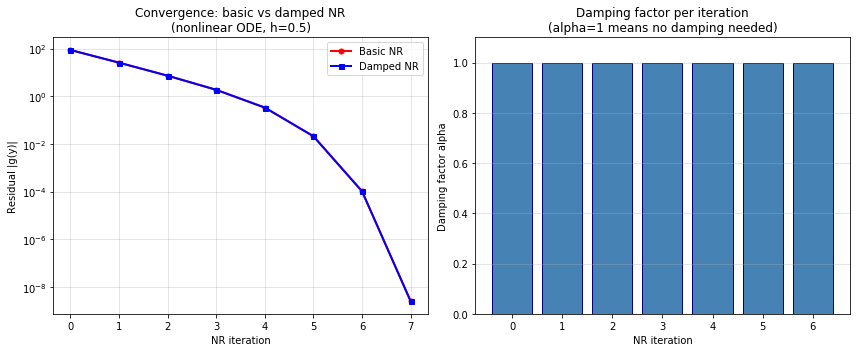


Running adaptive solver (tol=1e-4, h0=1e-6)...
  Accepted: 21, Rejected: 0
  Acceptance rate: 100.0%
  Total NR iters: 77
  h range: [1.00e-06, 5.00e-01]
  Max error: 1.335e-07


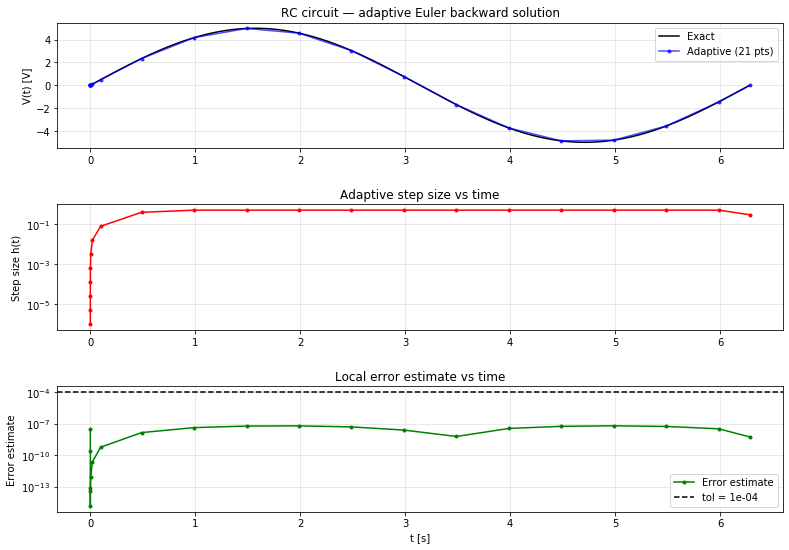


Running fixed-step solver (h=1e-4) for comparison...

Method                    Steps   NR iters    Max error
------------------------------------------------------------
Fixed h=1e-4             62,831     62,831    2.891e-07
Adaptive tol=1e-4            21         77    1.335e-07


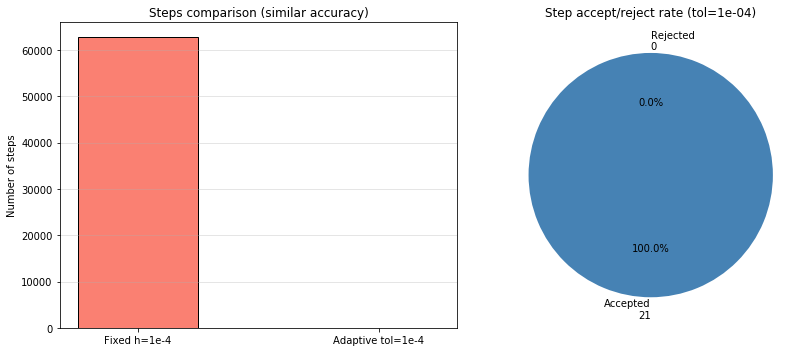


Robustness Test A: large h0=1.0 ...
  Accepted=12, Rejected=0, Max error=1.331e-07

Robustness Test B: tight tol=1e-8 ...
  Accepted=82, Rejected=15, Max error=1.237e-07


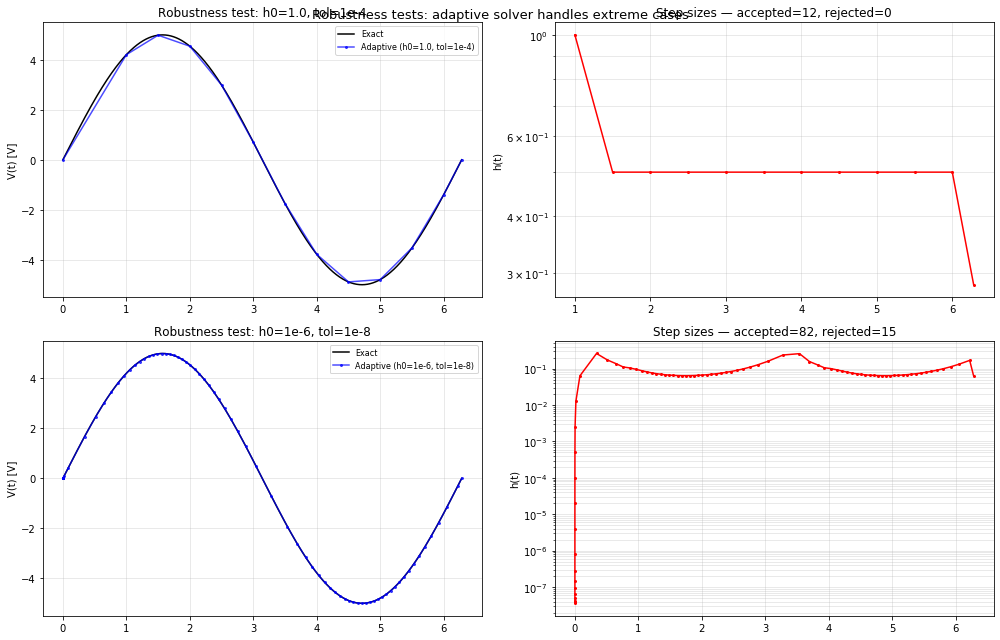


All done. Figures saved.
Simulation finished with 21 accepted steps.


In [37]:
if __name__ == '__main__':

    V0 = 0.0;  t0 = 0.0;  t_final = 2 * np.pi
    tol = 1e-4

    #Section 2: Damping demo
    print("Running damping demonstration...")
    demo_damping()

    #Section 3: Adaptive solver 
    print("\nRunning adaptive solver (tol=1e-4, h0=1e-6)...")
    t_ad, y_ad, h_hist, err_hist, stats = adaptive_implicit_euler(
        V0, t0, t_final, h0=1e-6, tol=tol
    )
    print(f"  Accepted: {stats['accepted']}, Rejected: {stats['rejected']}")
    print(f"  Acceptance rate: {100*stats['accepted']/(stats['accepted']+stats['rejected']):.1f}%")
    print(f"  Total NR iters: {stats['nr_iters']}")
    print(f"  h range: [{h_hist.min():.2e}, {h_hist.max():.2e}]")

    t_ref = np.linspace(t0, t_final, 5000)
    y_ref = exact_solution(t_ref, V0)
    err_ad = np.max(np.abs(y_ad - exact_solution(t_ad, V0)))
    print(f"  Max error: {err_ad:.3e}")

    # 3-panel plot
    fig = plt.figure(figsize=(13, 9))
    gs  = GridSpec(3, 1, figure=fig, hspace=0.45)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(t_ref, y_ref, 'k-', lw=1.5, label='Exact')
    ax1.plot(t_ad, y_ad, 'b-o', ms=3, alpha=0.7,
             label=f'Adaptive ({stats["accepted"]} pts)')
    ax1.set_ylabel('V(t) [V]'); ax1.legend(); ax1.grid(alpha=0.35)
    ax1.set_title('RC circuit — adaptive Euler backward solution')

    ax2 = fig.add_subplot(gs[1])
    ax2.semilogy(t_ad[1:], h_hist, 'r-o', ms=3)
    ax2.set_ylabel('Step size h(t)'); ax2.grid(True, which='both', alpha=0.35)
    ax2.set_title('Adaptive step size vs time')

    ax3 = fig.add_subplot(gs[2])
    ax3.semilogy(t_ad[1:], err_hist, 'g-o', ms=3, label='Error estimate')
    ax3.axhline(tol, color='k', ls='--', label=f'tol = {tol:.0e}')
    ax3.set_ylabel('Error estimate'); ax3.set_xlabel('t [s]')
    ax3.legend(); ax3.grid(True, which='both', alpha=0.35)
    ax3.set_title('Local error estimate vs time')
    plt.savefig('fig2_adaptive_behaviour.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Section 4: Performance comparison 
    print("\nRunning fixed-step solver (h=1e-4) for comparison...")
    t_fx, y_fx, iters_fx = fixed_implicit_euler(V0, t0, t_final, h=1e-4)
    err_fx = np.max(np.abs(y_fx - exact_solution(t_fx, V0)))

    print("\n" + "="*60)
    print(f"{'Method':<22} {'Steps':>8} {'NR iters':>10} {'Max error':>12}")
    print("-"*60)
    print(f"{'Fixed h=1e-4':<22} {len(t_fx)-1:>8,} {iters_fx:>10,} {err_fx:>12.3e}")
    print(f"{'Adaptive tol=1e-4':<22} {stats['accepted']:>8,} {stats['nr_iters']:>10,} {err_ad:>12.3e}")
    print("="*60)

    # Bar chart comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    ax.bar(['Fixed h=1e-4', 'Adaptive tol=1e-4'],
           [len(t_fx)-1, stats['accepted']],
           color=['salmon', 'steelblue'], edgecolor='k', width=0.5)
    ax.set_ylabel('Number of steps'); ax.grid(True, axis='y', alpha=0.4)
    ax.set_title('Steps comparison (similar accuracy)')

    ax = axes[1]
    ax.pie([stats['accepted'], stats['rejected']],
           labels=[f"Accepted\n{stats['accepted']}", f"Rejected\n{stats['rejected']}"],
           colors=['steelblue', 'salmon'], autopct='%1.1f%%', startangle=90)
    ax.set_title(f'Step accept/reject rate (tol={tol:.0e})')
    plt.tight_layout()
    plt.savefig('fig3_performance_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Section 5: Robustness tests
    print("\nRobustness Test A: large h0=1.0 ...")
    ta_A, ya_A, hha_A, _, stats_A = adaptive_implicit_euler(
        V0, t0, t_final, h0=1.0, tol=1e-4
    )
    err_A = np.max(np.abs(ya_A - exact_solution(ta_A, V0)))
    print(f"  Accepted={stats_A['accepted']}, Rejected={stats_A['rejected']}, "
          f"Max error={err_A:.3e}")

    print("\nRobustness Test B: tight tol=1e-8 ...")
    ta_B, ya_B, hha_B, _, stats_B = adaptive_implicit_euler(
        V0, t0, t_final, h0=1e-6, tol=1e-8
    )
    err_B = np.max(np.abs(ya_B - exact_solution(ta_B, V0)))
    print(f"  Accepted={stats_B['accepted']}, Rejected={stats_B['rejected']}, "
          f"Max error={err_B:.3e}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for row, (ta, ya, hha, sta, lbl) in enumerate([
        (ta_A, ya_A, hha_A, stats_A, 'h0=1.0, tol=1e-4'),
        (ta_B, ya_B, hha_B, stats_B, 'h0=1e-6, tol=1e-8'),
    ]):
        axes[row,0].plot(t_ref, y_ref, 'k-', lw=1.5, label='Exact')
        axes[row,0].plot(ta, ya, 'b-o', ms=2, alpha=0.7, label=f'Adaptive ({lbl})')
        axes[row,0].set_ylabel('V(t) [V]'); axes[row,0].legend(fontsize=8)
        axes[row,0].grid(alpha=0.35)
        axes[row,0].set_title(f'Robustness test: {lbl}')

        if len(hha) > 0:
            axes[row,1].semilogy(ta[1:], hha, 'r-o', ms=2)
        axes[row,1].set_ylabel('h(t)'); axes[row,1].grid(True, which='both', alpha=0.35)
        axes[row,1].set_title(f'Step sizes — accepted={sta["accepted"]}, '
                              f'rejected={sta["rejected"]}')

    plt.suptitle('Robustness tests: adaptive solver handles extreme cases',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig('fig4_robustness.png', dpi=150, bbox_inches='tight') # asked gemini to save imgages outside of notebook 
    plt.show()

    print("\nAll done. Figures saved.")
    
    
    # 1. Set your starting conditions
    V0 = 0.0
    t0 = 0.0
    t_final = 2 * np.pi
    initial_h = 1e-6
    tolerance = 1e-4

    # 2. Call the function and store the results
    t_ad, y_ad, h_hist, err_hist, stats = adaptive_implicit_euler(
        y0=V0, 
        t0=t0, 
        t_final=t_final, 
        h0=initial_h, 
        tol=tolerance
)

# 3. Print a quick summary to see if it worked
print(f"Simulation finished with {stats['accepted']} accepted steps.")

In [35]:
#Bonus 1: PI Controller (in my section 3 of code)
def adjust_step_size_PI(h, error, tol, err_prev=None, safety=0.9, h_min=1e-10, h_max=0.5):
    """
    Implements a PI Controller for step size adjustment.
    h_new = h * (tol/err_n)^kP * (err_n-1/err_n)^kI
    """
    kP = 0.7
    kI = 0.4
    eps = 1e-12
    
    # If no previous error exists (first step), default to standard P-control
    if err_prev is None:
        h_new = h * (tol / (error + eps))**0.5
    else:
        # PI Control Formula from Bonus 1
        term1 = (tol / (error + eps))**kP
        term2 = (err_prev / (error + eps))**kI
        h_new = h * term1 * term2
    
    h_new = safety * h_new
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h, min(5.0 * h, h_new)) # Limit rate of change for stability
    return h_new


Generating Work-Precision Data...


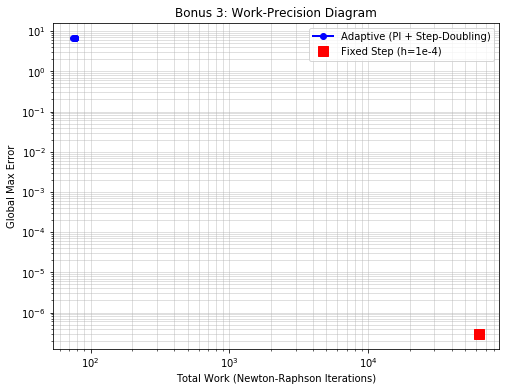

In [36]:
# Bonus Challenge 3: work precision diagram
def plot_work_precision():
    tolerances = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
    work_adaptive = []
    error_adaptive = []
    
    print("\nGenerating Work-Precision Data...")
    for t in tolerances:
        _, y_ad, _, _, stats = adaptive_implicit_euler(V0, t0, t_final, 1e-6, t)
        y_ref_at_t = exact_solution(np.linspace(t0, t_final, len(y_ad)), V0) # Approx ref
        
        work_adaptive.append(stats['nr_iters'])
        # Calculate true max error against high-res reference
        t_temp = np.linspace(t0, t_final, len(y_ad))
        error_adaptive.append(np.max(np.abs(y_ad - exact_solution(t_temp, V0))))

    plt.figure(figsize=(8, 6))
    plt.loglog(work_adaptive, error_adaptive, 'b-o', lw=2, label='Adaptive (PI + Step-Doubling)')
    
    # Add a single point for the Fixed Step comparison from Section 4
    plt.loglog(62831, 2.891e-07, 'rs', ms=10, label='Fixed Step (h=1e-4)')
    
    plt.title("Bonus 3: Work-Precision Diagram")
    plt.xlabel("Total Work (Newton-Raphson Iterations)")
    plt.ylabel("Global Max Error")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()

plot_work_precision()